In [1]:
#Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
resultados = []

In [3]:
#Cargamos resumen
df = pd.read_csv('Analisis GAC Full7agosto 2026(Resumen).csv', skiprows=5, nrows=30, thousands=",")
datos = df.iloc[:, [2, 3, 6, 15, 24]].copy()
datos.columns = ["Leads", "Efectivos", "Ventas", "SDC", "PDM"]
datos.head(5)

,Leads,Efectivos,Ventas,SDC,PDM
0,543,389,12,6,24
1,178,128,7,11,25
2,416,288,8,23,35
3,422,274,13,26,54
4,967,620,6,43,54


In [4]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Leads        0
Efectivos    0
Ventas       0
SDC          0
PDM          0
dtype: int64
Filas antes: 30
Filas completas: 30


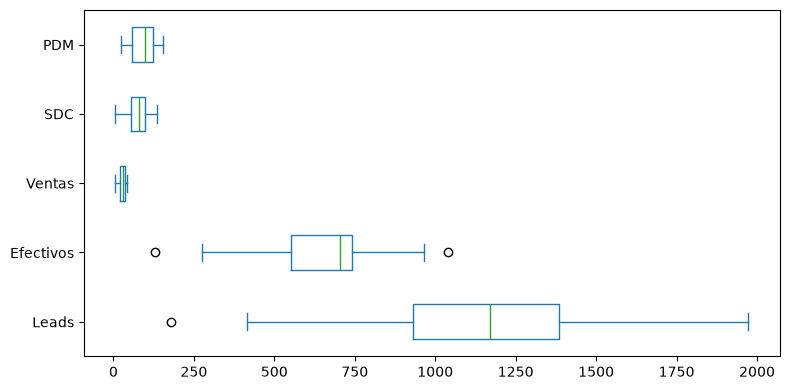

In [5]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [6]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Leads        0
Efectivos    0
Ventas       0
SDC          0
PDM          0
dtype: int64


Leads        0
Efectivos    0
Ventas       0
SDC          0
PDM          0
dtype: int64

,Leads,Efectivos,Ventas,SDC,PDM
Leads,1.000000,0.809103,0.497176,0.591564,0.545613
Efectivos,0.809103,1.000000,0.600694,0.687552,0.611646
Ventas,0.497176,0.600694,1.000000,0.803614,0.825500
SDC,0.591564,0.687552,0.803614,1.000000,0.876625
PDM,0.545613,0.611646,0.825500,0.876625,1.000000


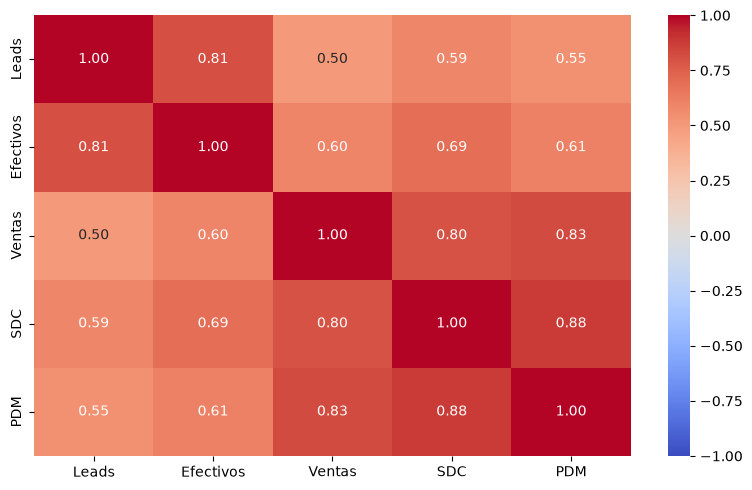

In [7]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.6006943535798808 R2: 0.3608337064227508
Pendiente: 0.031088012405989657 Intercepto: 7.474484702197017


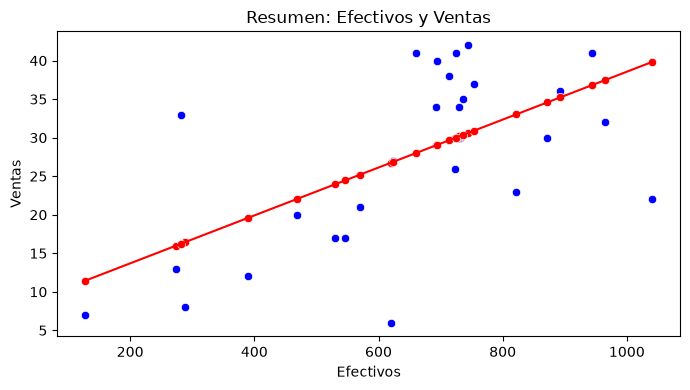

In [8]:
# Efectivos y Ventas: r = 0.601 y R2 = 0.361.
# Mas leads efectivos se asocian con mas ventas, pero el volumen no explica todo el resultado.
Vars_Indep = datos_limpios[['Efectivos']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Efectivos']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Efectivos', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='Efectivos', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Efectivos', y="Predicciones", color="red", data=grafica)
plt.title('Resumen: Efectivos y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Resumen', 'Efectivos', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

r: 0.8255004923240131 R2: 0.6814510628271881
Pendiente: 0.2498016381123507 Intercepto: 4.493480715865992


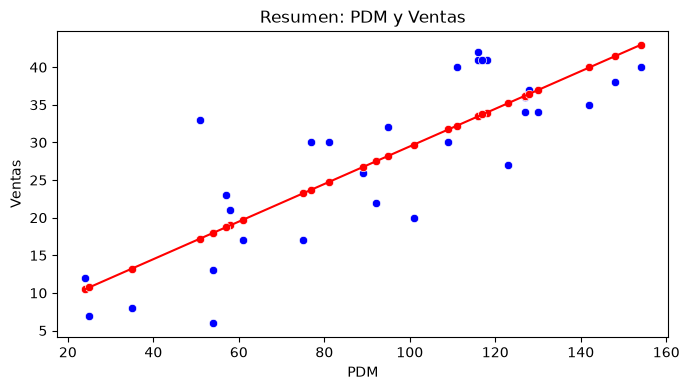

In [9]:
# PDM y Ventas: r = 0.826 y R2 = 0.681.
# Los meses con mas pruebas de manejo registran mas ventas; conviene probar mejoras en esta etapa.
Vars_Indep = datos_limpios[['PDM']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['PDM']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='PDM', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='PDM', y="Predicciones", color="red", data=grafica)
plt.title('Resumen: PDM y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Resumen', 'PDM', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

In [10]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_01_limpia.csv", index=False)

In [11]:
#Cargamos solicitudes de credito
df = pd.read_csv('Analisis GAC Full7agosto 2026(SDC ).csv', header=None, dtype=str)
datos = df.iloc[[5, 6, 8, 9], 1:32].T.copy()
datos.columns = ["Generadas", "Aprobadas", "Rechazadas", "Formalizadas"]
datos.head(5)

,Generadas,Aprobadas,Rechazadas,Formalizadas
1,5,1,4,1
2,6,2,4,1
3,11,7,4,5
4,23,14,9,11
5,26,8,14,3


In [12]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Generadas       0
Aprobadas       0
Rechazadas      0
Formalizadas    0
dtype: int64
Filas antes: 31
Filas completas: 31


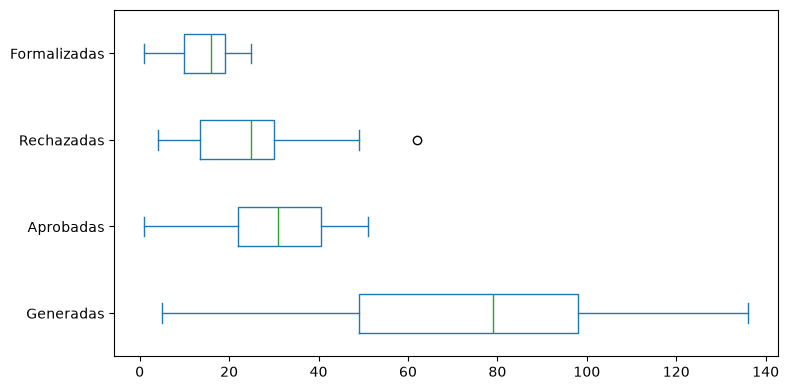

In [13]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [14]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Generadas       0
Aprobadas       0
Rechazadas      0
Formalizadas    0
dtype: int64


Generadas       0
Aprobadas       0
Rechazadas      0
Formalizadas    0
dtype: int64

,Generadas,Aprobadas,Rechazadas,Formalizadas
Generadas,1.000000,0.896295,0.881383,0.880581
Aprobadas,0.896295,1.000000,0.725853,0.932941
Rechazadas,0.881383,0.725853,1.000000,0.744203
Formalizadas,0.880581,0.932941,0.744203,1.000000


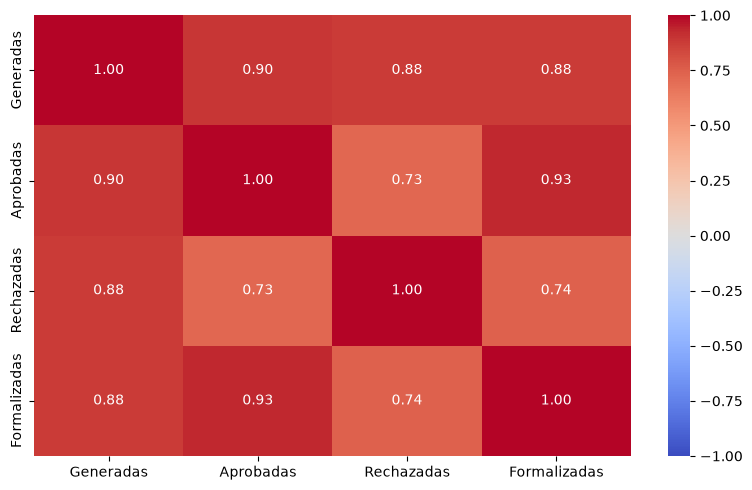

In [15]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.9329411615500491 R2: 0.8703792109143552
Pendiente: 0.4760880650954483 Intercepto: 0.3824357581535569


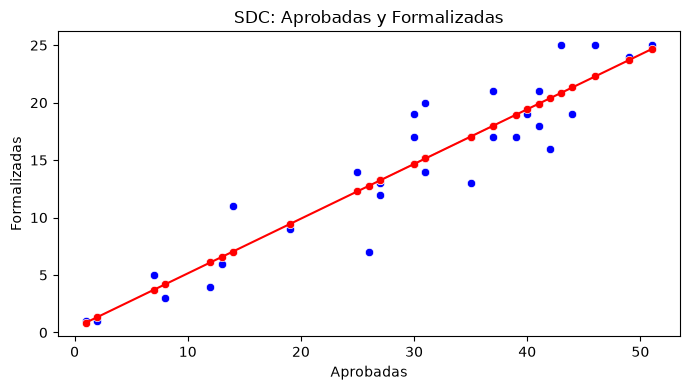

In [16]:
# Aprobadas y Formalizadas: r = 0.933 y R2 = 0.870.
# Aprobadas y formalizadas se relacionan fuertemente; pertenecer al mismo proceso influye en el ajuste.
Vars_Indep = datos_limpios[['Aprobadas']]
Var_Dep = datos_limpios['Formalizadas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Aprobadas']['Formalizadas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Aprobadas', y='Formalizadas', color="blue", data=grafica)
sns.scatterplot(x='Aprobadas', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Aprobadas', y="Predicciones", color="red", data=grafica)
plt.title('SDC: Aprobadas y Formalizadas')
plt.tight_layout()
plt.show()
resultados.append(['SDC', 'Aprobadas', 'Formalizadas', len(datos_limpios), coef_Correl, coef_Deter])

In [17]:
# Se registran 447 formalizaciones y 914 aprobaciones: una razon de 48.9%.
# Son totales del periodo; no necesariamente corresponden a la misma cohorte de solicitudes.
print("Aprobadas:", datos["Aprobadas"].sum())
print("Formalizadas:", datos["Formalizadas"].sum())
print("Formalizacion porcentual:", 100 * datos["Formalizadas"].sum() / datos["Aprobadas"].sum())

Aprobadas: 914.0
Formalizadas: 447.0
Formalizacion porcentual: 48.905908096280086


In [18]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_02_limpia.csv", index=False)

In [19]:
#Cargamos funnel
df = pd.read_csv('Analisis GAC Full7agosto 2026(Funnel).csv', header=None, dtype=str)
datos = pd.DataFrame()
datos["Programadas"] = df.iloc[[8,22,36,50,64,78,92,107,122,137,152,167,182,197,212,227,242,257], 2].values
datos["Efectivas"] = df.iloc[[9,23,37,51,65,79,93,108,123,138,153,168,183,198,213,228,243,258], 2].values
datos["PDM"] = df.iloc[[10,24,38,52,66,80,94,109,124,139,154,169,184,199,214,229,244,259], 2].values
datos["Aprobadas"] = df.iloc[[12,26,40,54,68,82,96,111,126,141,156,171,186,201,216,231,246,261], 2].values
datos["Ventas"] = df.iloc[[5,19,33,47,61,75,89,104,119,134,149,164,179,194,209,224,239,254], 2].values
datos.head(5)

,Programadas,Efectivas,PDM,Aprobadas,Ventas
0,189,109,86,29,26
1,117,101,97,27,20
2,181,140,77,30,30
3,174,114,81,35,30
4,166,157,121,40,34


In [20]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Programadas    0
Efectivas      0
PDM            0
Aprobadas      0
Ventas         0
dtype: int64
Filas antes: 18
Filas completas: 18


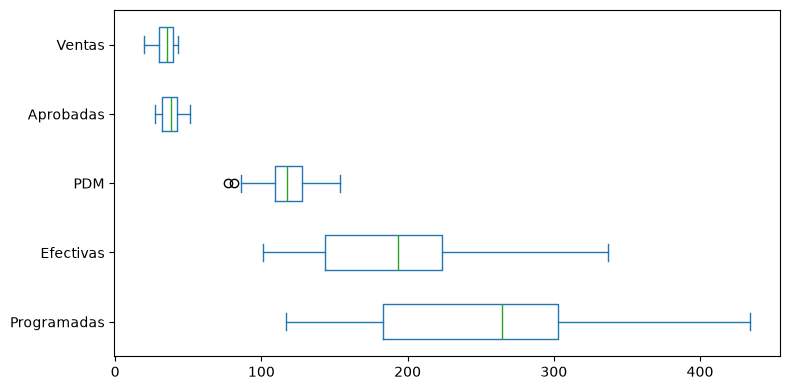

In [21]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [22]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Programadas    0
Efectivas      0
PDM            0
Aprobadas      0
Ventas         0
dtype: int64


Programadas    0
Efectivas      0
PDM            0
Aprobadas      0
Ventas         0
dtype: int64

,Programadas,Efectivas,PDM,Aprobadas,Ventas
Programadas,1.000000,0.955216,0.496667,0.349805,0.335212
Efectivas,0.955216,1.000000,0.518758,0.374067,0.342661
PDM,0.496667,0.518758,1.000000,0.474863,0.535350
Aprobadas,0.349805,0.374067,0.474863,1.000000,0.822709
Ventas,0.335212,0.342661,0.535350,0.822709,1.000000


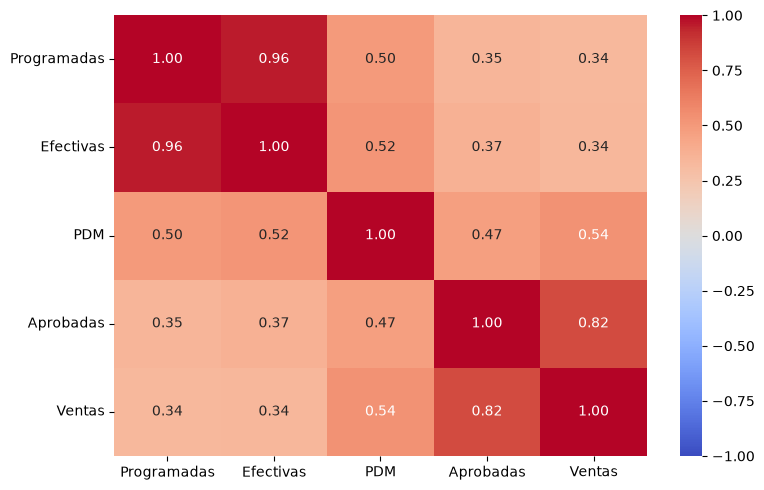

In [23]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.9552159278865178 R2: 0.9124374688881011
Pendiente: 0.7402786974353907 Intercepto: 0.49590848445916436


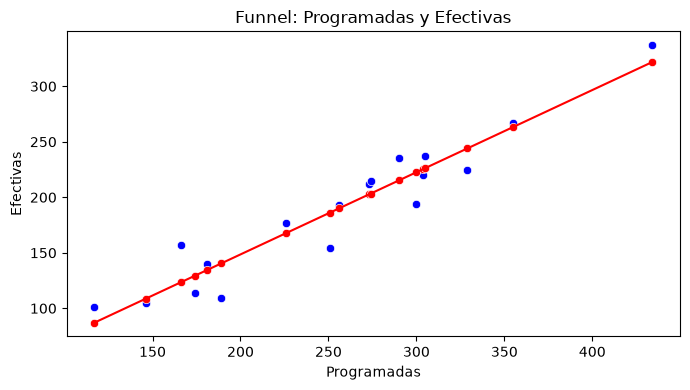

In [24]:
# Programadas y Efectivas: r = 0.955 y R2 = 0.912.
# Mas citas programadas se asocian con mas asistencias, aunque una parte no se concreta.
Vars_Indep = datos_limpios[['Programadas']]
Var_Dep = datos_limpios['Efectivas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Programadas']['Efectivas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Programadas', y='Efectivas', color="blue", data=grafica)
sns.scatterplot(x='Programadas', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Programadas', y="Predicciones", color="red", data=grafica)
plt.title('Funnel: Programadas y Efectivas')
plt.tight_layout()
plt.show()
resultados.append(['Funnel', 'Programadas', 'Efectivas', len(datos_limpios), coef_Correl, coef_Deter])

r: 0.34266084633677923 R2: 0.11741645561223812
Pendiente: 0.03342493253471995 Intercepto: 28.20125715790166


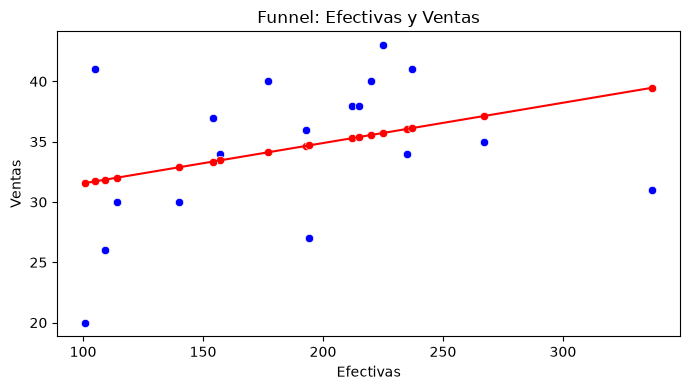

In [25]:
# Efectivas y Ventas: r = 0.343 y R2 = 0.117.
# La relacion entre asistencias y ventas es debil; tambien hay que revisar las etapas posteriores.
Vars_Indep = datos_limpios[['Efectivas']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Efectivas']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Efectivas', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='Efectivas', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Efectivas', y="Predicciones", color="red", data=grafica)
plt.title('Funnel: Efectivas y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Funnel', 'Efectivas', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

r: 0.8227093199279021 R2: 0.6768506250962307
Pendiente: 0.6913776257938443 Intercepto: 8.304469956033234


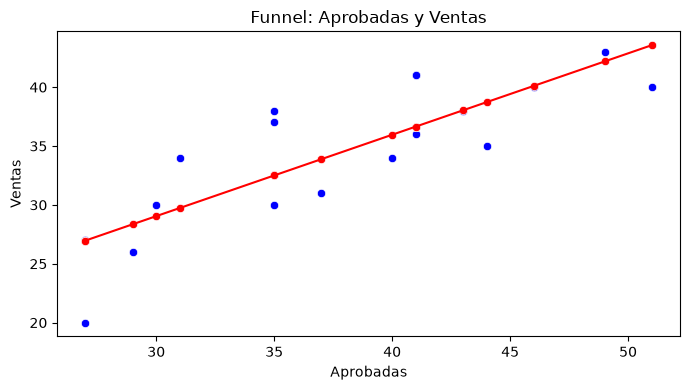

In [26]:
# Aprobadas y Ventas: r = 0.823 y R2 = 0.677.
# Las aprobaciones de credito se asocian con las ventas, sin demostrar que las causen.
Vars_Indep = datos_limpios[['Aprobadas']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Aprobadas']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Aprobadas', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='Aprobadas', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Aprobadas', y="Predicciones", color="red", data=grafica)
plt.title('Funnel: Aprobadas y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Funnel', 'Aprobadas', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

In [27]:
# Se registran 3392 citas efectivas frente a 4570 programadas: una razon de 74.2%.
# Conviene revisar cancelaciones y cambios de fecha antes de considerar la diferencia como perdida.
print("Citas programadas:", datos["Programadas"].sum())
print("Citas efectivas:", datos["Efectivas"].sum())
print("Asistencia porcentual:", 100 * datos["Efectivas"].sum() / datos["Programadas"].sum())

Citas programadas: 4570.0
Citas efectivas: 3392.0
Asistencia porcentual: 74.22319474835886


In [28]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_03_limpia.csv", index=False)

In [29]:
#Cargamos datos de Facebook
df = pd.read_csv('Analisis GAC Full7agosto 2026(CPL FACEBOOK).csv', header=None, dtype=str)
datos = df.iloc[[1, 2, 3], 1:14].T.copy()
datos.columns = ["Campanas", "Leads", "Presupuesto"]
datos["Presupuesto"] = datos["Presupuesto"].str.replace("$", "", regex=False)
datos["Presupuesto"] = datos["Presupuesto"].str.replace(",", "", regex=False)
datos.head(5)

,Campanas,Leads,Presupuesto
1,12,256,29737.00
2,12,230,41463.00
3,15,387,58316.00
4,14,288,41073.00
5,13,260,43532.00


In [30]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Campanas       0
Leads          0
Presupuesto    0
dtype: int64
Filas antes: 13
Filas completas: 13


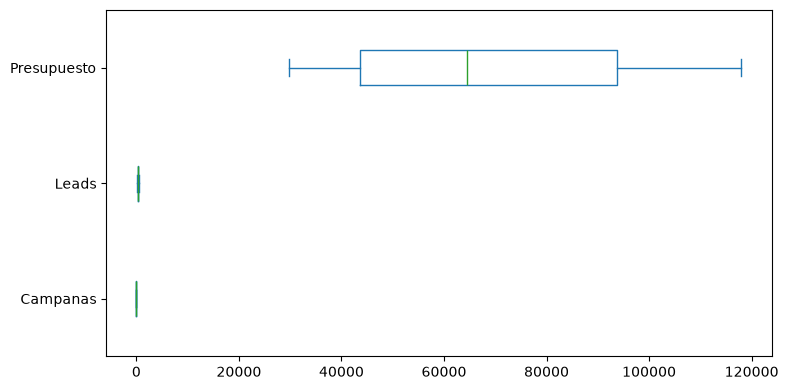

In [31]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [32]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Campanas       0
Leads          0
Presupuesto    0
dtype: int64


Campanas       0
Leads          0
Presupuesto    0
dtype: int64

,Campanas,Leads,Presupuesto
Campanas,1.000000,-0.018257,-0.674121
Leads,-0.018257,1.000000,0.590660
Presupuesto,-0.674121,0.590660,1.000000


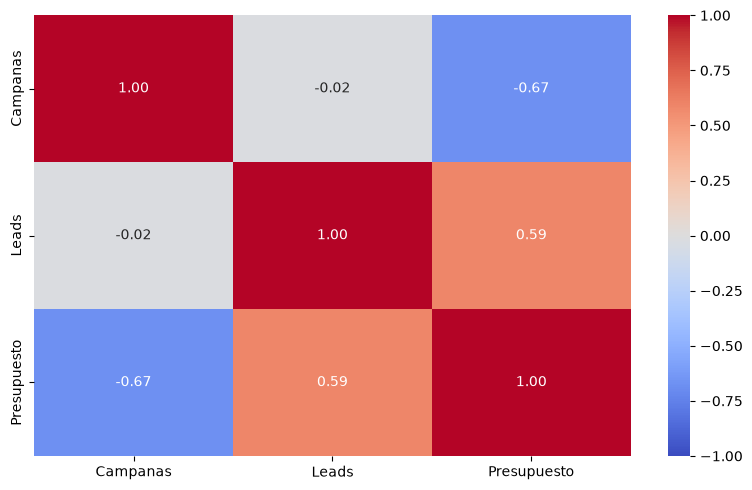

In [33]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.590659784716823 R2: 0.3488789812817237
Pendiente: 0.0012731562898232421 Intercepto: 208.41577847363902


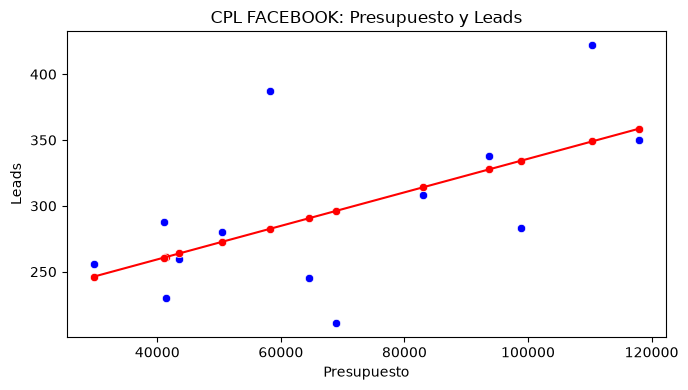

In [34]:
# Presupuesto y Leads: r = 0.591 y R2 = 0.349.
# El presupuesto se relaciona con la captacion, pero esta base no muestra ventas ni rentabilidad.
Vars_Indep = datos_limpios[['Presupuesto']]
Var_Dep = datos_limpios['Leads']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Presupuesto']['Leads']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Presupuesto', y='Leads', color="blue", data=grafica)
sns.scatterplot(x='Presupuesto', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Presupuesto', y="Predicciones", color="red", data=grafica)
plt.title('CPL FACEBOOK: Presupuesto y Leads')
plt.tight_layout()
plt.show()
resultados.append(['CPL FACEBOOK', 'Presupuesto', 'Leads', len(datos_limpios), coef_Correl, coef_Deter])

In [35]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_04_limpia.csv", index=False)

In [36]:
#Cargamos marketing
df = pd.read_csv('Analisis GAC Full7agosto 2026(Marketing).csv', header=None, dtype=str)
datos = df.iloc[[7, 3, 4], 12:30].T.copy()
datos.columns = ["Provision", "Leads", "Ventas"]
datos["Provision"] = datos["Provision"].str.replace("$", "", regex=False)
datos["Provision"] = datos["Provision"].str.replace(",", "", regex=False)
datos["Leads"] = datos["Leads"].str.replace(",", "", regex=False)
datos.head(5)

,Provision,Leads,Ventas
12,346790.94,1042,26
13,423573.75,561,20
14,242750.78,925,30
15,517105.00,1083,30
16,570803.67,815,34


In [37]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Provision    0
Leads        0
Ventas       0
dtype: int64
Filas antes: 18
Filas completas: 18


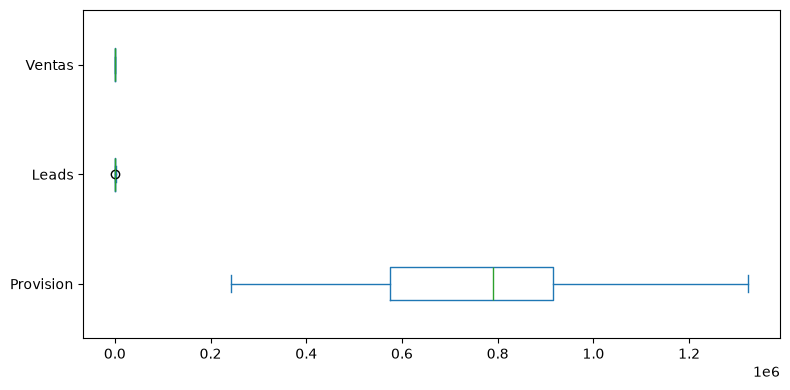

In [38]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [39]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Provision    0
Leads        0
Ventas       0
dtype: int64


Provision    0
Leads        0
Ventas       0
dtype: int64

,Provision,Leads,Ventas
Provision,1.00000,0.660050,0.645860
Leads,0.66005,1.000000,0.523104
Ventas,0.64586,0.523104,1.000000


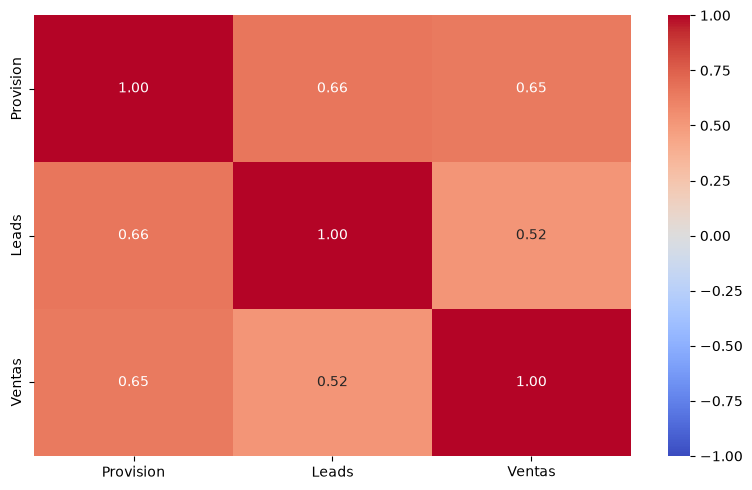

In [40]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.6458599579797951 R2: 0.41713508532166277
Pendiente: 1.3294427512271943e-05 Intercepto: 24.05492998806092


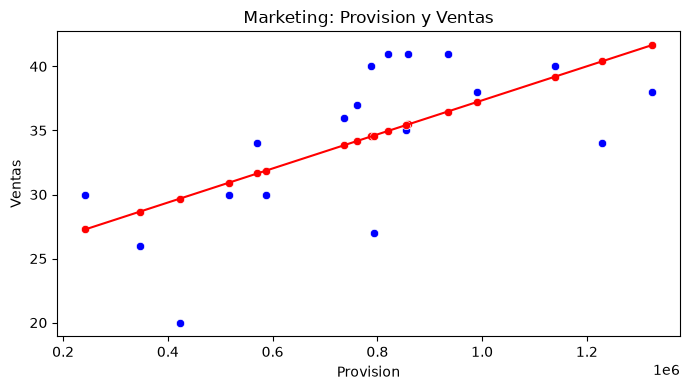

In [41]:
# Provision y Ventas: r = 0.646 y R2 = 0.417.
# La provision de marketing se asocia con las ventas; no equivale al gasto ejercido ni prueba un efecto causal.
Vars_Indep = datos_limpios[['Provision']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Provision']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Provision', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='Provision', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Provision', y="Predicciones", color="red", data=grafica)
plt.title('Marketing: Provision y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Marketing', 'Provision', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

In [42]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_05_limpia.csv", index=False)

In [43]:
#Cargamos citas digitales
df = pd.read_csv('Analisis GAC Full7agosto 2026(Citas Digital).csv', dtype=str)
print("Filas del archivo:", len(df))
df = df.dropna(subset=["Nombre Cliente "])
print("Clientes registrados:", len(df))
datos = df[["PDM", "SDC", "Venta"]].copy()
datos = datos.dropna()
datos = datos[(datos["PDM"] == "TRUE") | (datos["PDM"] == "FALSE")]
datos = datos[(datos["SDC"] == "TRUE") | (datos["SDC"] == "FALSE")]
datos = datos[(datos["Venta"] == "TRUE") | (datos["Venta"] == "FALSE")]
datos["PDM"] = datos["PDM"].str.replace("TRUE", "1", regex=False).str.replace("FALSE", "0", regex=False)
datos["SDC"] = datos["SDC"].str.replace("TRUE", "1", regex=False).str.replace("FALSE", "0", regex=False)
datos["Venta"] = datos["Venta"].str.replace("TRUE", "1", regex=False).str.replace("FALSE", "0", regex=False)
datos.head(5)

Filas del archivo: 1048575
Clientes registrados: 668


,PDM,SDC,Venta
0,1,0,0
1,0,0,0
2,0,0,0
3,0,0,1
4,1,0,0


In [44]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: PDM      0
SDC      0
Venta    0
dtype: int64
Filas antes: 664
Filas completas: 664


In [45]:
# Los valores 0 y 1 son categorias validas, aunque haya pocas ventas.
# Se conservan ambos y no se sustituyen con la mediana.
datos_limpios = datos.copy()
print("Minimos:", datos_limpios.min())
print("Maximos:", datos_limpios.max())

Minimos: PDM      0.0
SDC      0.0
Venta    0.0
dtype: float64
Maximos: PDM      1.0
SDC      1.0
Venta    1.0
dtype: float64


,PDM,SDC,Venta
PDM,1.000000,0.124510,0.166971
SDC,0.124510,1.000000,0.239078
Venta,0.166971,0.239078,1.000000


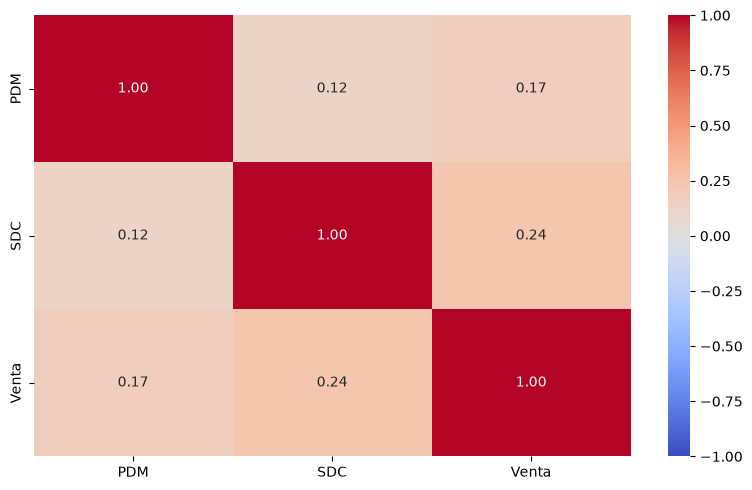

In [46]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.16697146922394304 R2: 0.027879471534801747
Pendiente: 0.09429442508710786 Intercepto: 0.0396341463414635


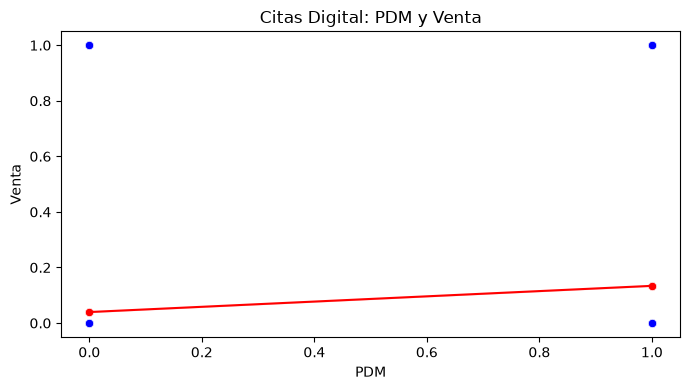

In [47]:
# PDM y Venta: r = 0.167 y R2 = 0.028.
# La recta compara promedios entre grupos; no debe usarse como una probabilidad individual de venta.
Vars_Indep = datos_limpios[['PDM']]
Var_Dep = datos_limpios['Venta']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['PDM']['Venta']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='PDM', y='Venta', color="blue", data=grafica)
sns.scatterplot(x='PDM', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='PDM', y="Predicciones", color="red", data=grafica)
plt.title('Citas Digital: PDM y Venta')
plt.tight_layout()
plt.show()
resultados.append(['Citas Digital', 'PDM', 'Venta', len(datos_limpios), coef_Correl, coef_Deter])

r: 0.23907767086076306 R2: 0.05715813270420722
Pendiente: 0.13711398090960145 Intercepto: 0.03076923076923073


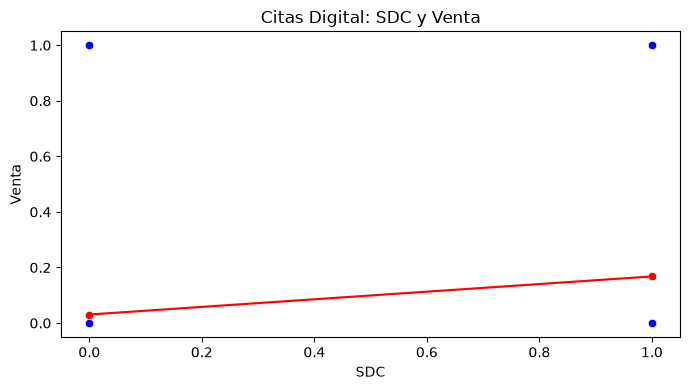

In [48]:
# SDC y Venta: r = 0.239 y R2 = 0.057.
# La solicitud puede depender del avance de la compra; esta asociacion no demuestra causalidad.
Vars_Indep = datos_limpios[['SDC']]
Var_Dep = datos_limpios['Venta']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['SDC']['Venta']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='SDC', y='Venta', color="blue", data=grafica)
sns.scatterplot(x='SDC', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='SDC', y="Predicciones", color="red", data=grafica)
plt.title('Citas Digital: SDC y Venta')
plt.tight_layout()
plt.show()
resultados.append(['Citas Digital', 'SDC', 'Venta', len(datos_limpios), coef_Correl, coef_Deter])

In [49]:
# La venta registrada fue de 13.39% con PDM y 3.96% sin PDM.
# Los grupos pueden tener distinto interes inicial; la diferencia no prueba el efecto de la prueba.
tabla = datos_limpios.groupby('PDM')['Venta'].agg(["count", "sum", "mean"])
tabla.columns = ["Registros", "Ventas", "Conversion"]
tabla["Conversion"] = tabla["Conversion"] * 100
tabla.round(2)

,Registros,Ventas,Conversion
PDM,,,
0.0,328,13.0,3.96
1.0,336,45.0,13.39


In [50]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_06_limpia.csv", index=False)

In [51]:
#Comparamos ventas con y sin solicitud de credito
tabla_sdc = datos_limpios.groupby("SDC")["Venta"].agg(["count", "sum", "mean"])
tabla_sdc.columns = ["Registros", "Ventas", "Conversion"]
tabla_sdc["Conversion"] = tabla_sdc["Conversion"] * 100
tabla_sdc.round(2)

,Registros,Ventas,Conversion
SDC,,,
0.0,390,12.0,3.08
1.0,274,46.0,16.79


In [52]:
#Cargamos leads
df = pd.read_csv('Analisis GAC Full7agosto 2026(Base de Leads).csv', dtype=str)
df = df.dropna(subset=["Temperatura", " "])
datos = pd.DataFrame()
datos["Muy_interesado"] = (df["Temperatura"] == "Lead Muy Interesado").astype(int)
datos["Venta"] = (df[" "] == "1 Ventas").astype(int)
datos.head(5)

,Muy_interesado,Venta
0,1,1
1,0,0
2,1,1
3,1,0
4,0,0


In [53]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Muy_interesado    0
Venta             0
dtype: int64
Filas antes: 210
Filas completas: 210


In [54]:
# Los valores 0 y 1 son categorias validas, aunque haya pocas ventas.
# Se conservan ambos y no se sustituyen con la mediana.
datos_limpios = datos.copy()
print("Minimos:", datos_limpios.min())
print("Maximos:", datos_limpios.max())

Minimos: Muy_interesado    0.0
Venta             0.0
dtype: float64
Maximos: Muy_interesado    1.0
Venta             1.0
dtype: float64


,Muy_interesado,Venta
Muy_interesado,1.000000,0.596285
Venta,0.596285,1.000000


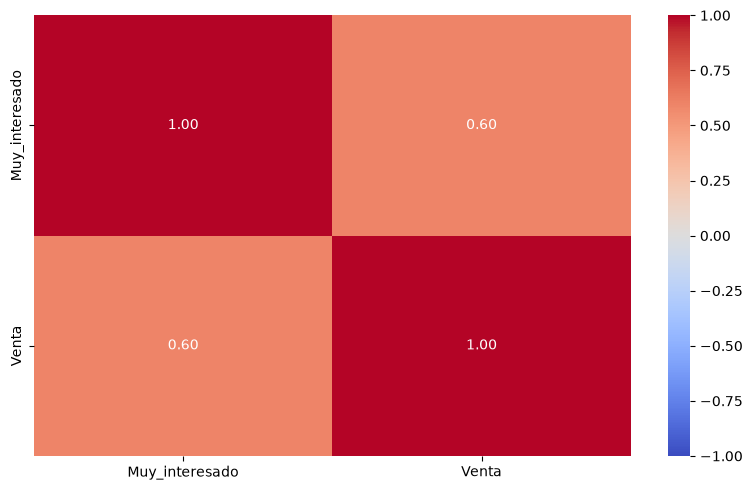

In [55]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.5962847939999436 R2: 0.3555555555555556
Pendiente: 0.42328042328042237 Intercepto: 0.005291005291005374


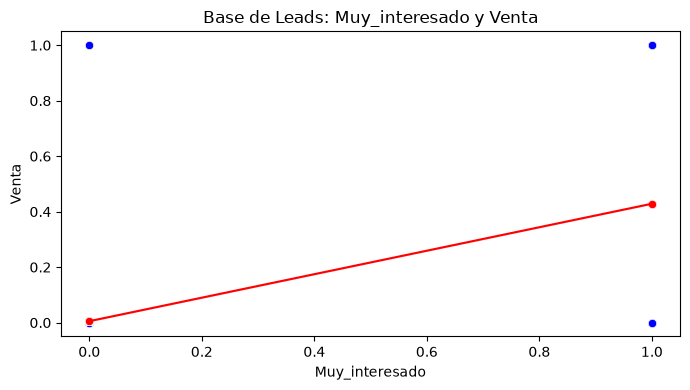

In [56]:
# Muy_interesado y Venta: r = 0.596 y R2 = 0.356.
# La temperatura pudo actualizarse despues de la venta; hay que revisar cuando se registro.
Vars_Indep = datos_limpios[['Muy_interesado']]
Var_Dep = datos_limpios['Venta']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Muy_interesado']['Venta']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Muy_interesado', y='Venta', color="blue", data=grafica)
sns.scatterplot(x='Muy_interesado', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Muy_interesado', y="Predicciones", color="red", data=grafica)
plt.title('Base de Leads: Muy_interesado y Venta')
plt.tight_layout()
plt.show()
resultados.append(['Base de Leads', 'Muy_interesado', 'Venta', len(datos_limpios), coef_Correl, coef_Deter])

In [57]:
# Se registro venta en 9 de 21 leads muy interesados y en 1 de 189 de los demas.
# La diferencia es descriptiva; no valida por si sola una regla para priorizar clientes.
tabla = datos_limpios.groupby('Muy_interesado')['Venta'].agg(["count", "sum", "mean"])
tabla.columns = ["Registros", "Ventas", "Conversion"]
tabla["Conversion"] = tabla["Conversion"] * 100
tabla.round(2)

,Registros,Ventas,Conversion
Muy_interesado,,,
0.0,189,1.0,0.53
1.0,21,9.0,42.86


In [58]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_07_limpia.csv", index=False)

In [59]:
#Cargamos analisis de piso
df = pd.read_csv('Analisis GAC Full7agosto 2026(Analisis de Piso ).csv', header=None, dtype=str)
df = df.iloc[4:44].copy()
df = df[(df[0] != "CASA") & (df[0] != "Demo Vendedor") & (df[0] != "USUARIO DE BDC Y CASA ") & (df[0] != "sys_competition")]
datos = df.iloc[:, [40, 43, 44]].copy()
datos.columns = ["Ventas", "PDM", "SDC"]
datos.head(5)

,Ventas,PDM,SDC
4,1,1,5
5,18,59,40
6,NaN,1,1
7,8,28,31
8,15,64,30


In [60]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Ventas    12
PDM        0
SDC        0
dtype: int64
Filas antes: 36
Filas completas: 24


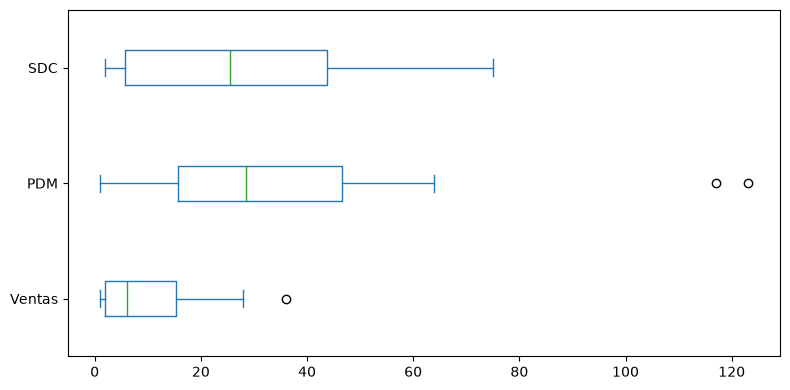

In [61]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [62]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Ventas    0
PDM       0
SDC       0
dtype: int64


Ventas    0
PDM       0
SDC       0
dtype: int64

,Ventas,PDM,SDC
Ventas,1.000000,0.872037,0.868783
PDM,0.872037,1.000000,0.829804
SDC,0.868783,0.829804,1.000000


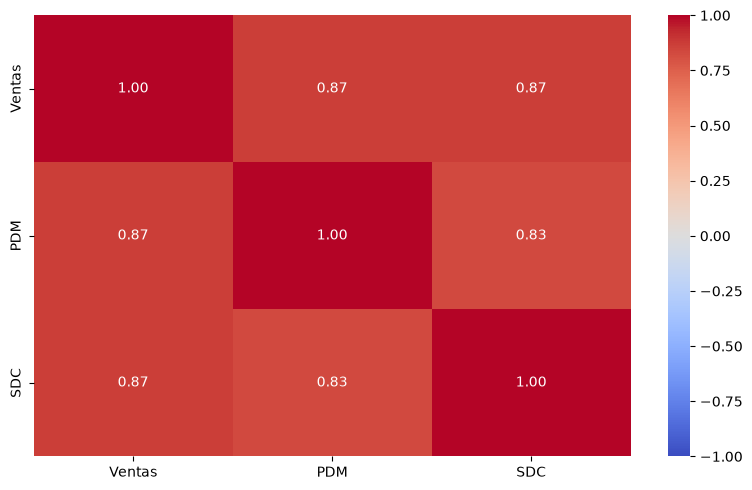

In [63]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.8720368887052768 R2: 0.7604483352627791
Pendiente: 0.26891353683183755 Intercepto: 0.3362782486002782


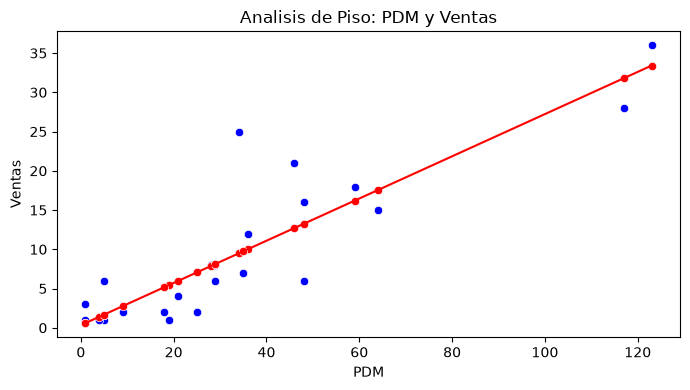

In [64]:
# PDM y Ventas: r = 0.872 y R2 = 0.760.
# Los acumulados pueden depender de la antiguedad del asesor; no miden por si solos su eficacia.
Vars_Indep = datos_limpios[['PDM']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['PDM']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='PDM', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='PDM', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='PDM', y="Predicciones", color="red", data=grafica)
plt.title('Analisis de Piso: PDM y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['Analisis de Piso', 'PDM', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

In [65]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_08_limpia.csv", index=False)

In [66]:
#Cargamos leads por canal
df = pd.read_csv('Analisis GAC Full7agosto 2026(Leads por Canal).csv', header=None, dtype=str)
datos = df.iloc[4:10, 2:31].T.copy()
datos.columns = ["Piso", "Plazas", "Eventos", "Planta", "Digitales", "Otros"]
datos.head(5)

,Piso,Plazas,Eventos,Planta,Digitales,Otros
2,329,0,7,6,6,195
3,19,0,0,52,5,102
4,76,25,5,127,18,165
5,87,28,0,60,69,178
6,55,68,71,376,87,310


In [67]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Piso         0
Plazas       0
Eventos      0
Planta       0
Digitales    0
Otros        0
dtype: int64
Filas antes: 29
Filas completas: 29


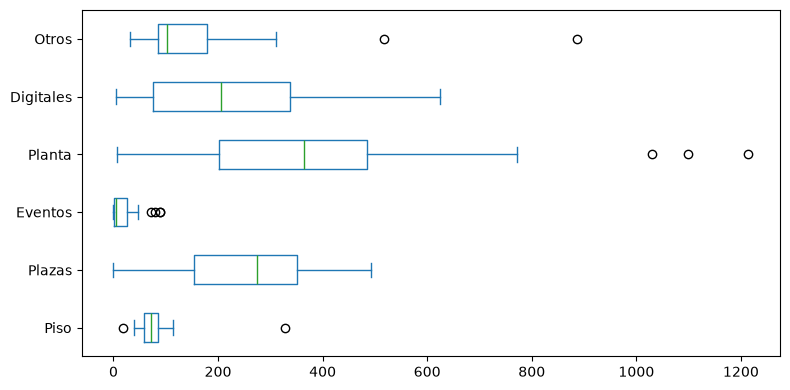

In [68]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [69]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Piso         1
Plazas       0
Eventos      0
Planta       0
Digitales    0
Otros        1
dtype: int64


Piso         0
Plazas       0
Eventos      0
Planta       0
Digitales    0
Otros        0
dtype: int64

,Piso,Plazas,Eventos,Planta,Digitales,Otros
Piso,1.000000,0.449063,0.285625,-0.212493,0.401788,-0.164618
Plazas,0.449063,1.000000,0.174758,-0.059224,0.769543,-0.414626
Eventos,0.285625,0.174758,1.000000,-0.028907,0.304899,-0.047618
Planta,-0.212493,-0.059224,-0.028907,1.000000,-0.068160,0.332684
Digitales,0.401788,0.769543,0.304899,-0.068160,1.000000,-0.223876
Otros,-0.164618,-0.414626,-0.047618,0.332684,-0.223876,1.000000


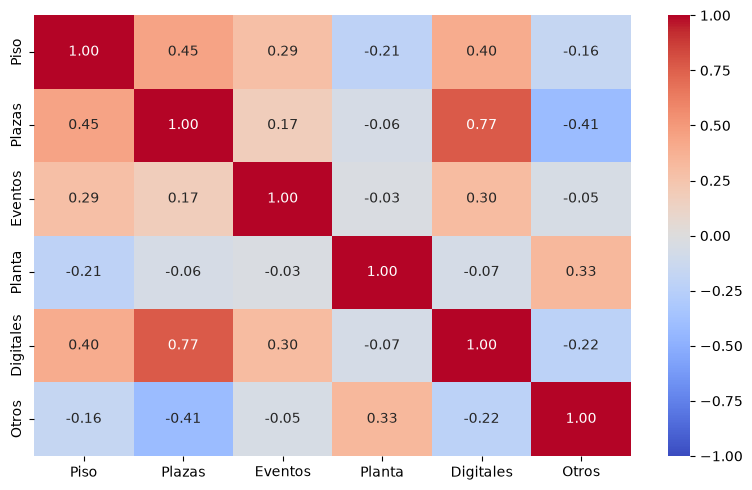

In [70]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: 0.7695433900037615 R2: 0.5921970290984813
Pendiente: 0.8971293835148891 Intercepto: -0.7393650995722112


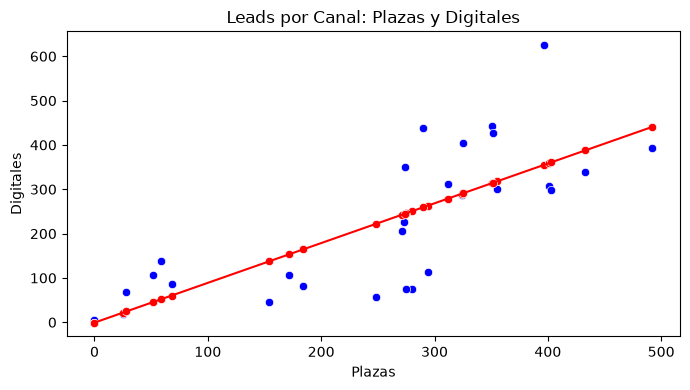

In [71]:
# Plazas y Digitales: r = 0.770 y R2 = 0.592.
# Los canales crecieron juntos; esto no indica cual convierte mejor a ventas.
Vars_Indep = datos_limpios[['Plazas']]
Var_Dep = datos_limpios['Digitales']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Plazas']['Digitales']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Plazas', y='Digitales', color="blue", data=grafica)
sns.scatterplot(x='Plazas', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Plazas', y="Predicciones", color="red", data=grafica)
plt.title('Leads por Canal: Plazas y Digitales')
plt.tight_layout()
plt.show()
resultados.append(['Leads por Canal', 'Plazas', 'Digitales', len(datos_limpios), coef_Correl, coef_Deter])

In [72]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_09_limpia.csv", index=False)

In [73]:
#Cargamos ventas
df = pd.read_csv('Analisis GAC Full7agosto 2026(TOPS VENTAS).csv', header=None, dtype=str)
datos = df.iloc[[3, 62, 74, 80], 1:6].T.copy()
datos.columns = ["Ventas", "Cita_efectiva_pct", "SDC_aprobada_pct", "Formalizacion_pct"]
datos["Cita_efectiva_pct"] = datos["Cita_efectiva_pct"].str.replace("%", "", regex=False)
datos["SDC_aprobada_pct"] = datos["SDC_aprobada_pct"].str.replace("%", "", regex=False)
datos["Formalizacion_pct"] = datos["Formalizacion_pct"].str.replace("%", "", regex=False)
datos.head(5)

,Ventas,Cita_efectiva_pct,SDC_aprobada_pct,Formalizacion_pct
1,37,18,31,60
2,32,32,45,46
3,41,20,48,44
4,41,36,55,39
5,35,33,46,41


In [74]:
#Limpieza de datos
datos = datos.astype(float)
print("Nulos por columna:", datos.isnull().sum())
print("Filas antes:", len(datos))
datos = datos.dropna().copy()
print("Filas completas:", len(datos))

Nulos por columna: Ventas               0
Cita_efectiva_pct    0
SDC_aprobada_pct     0
Formalizacion_pct    0
dtype: int64
Filas antes: 5
Filas completas: 5


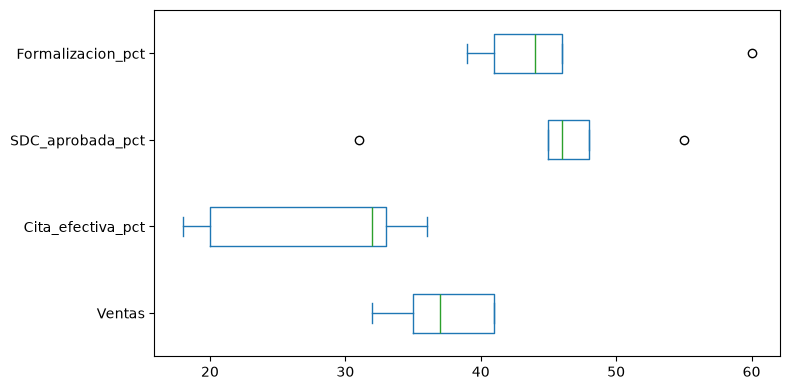

In [75]:
#Generamos grafica de cajas
datos.plot(kind="box", vert=False, figsize=(8, 4))
plt.tight_layout()
plt.show()

In [76]:
#Tratamos valores atipicos
y = datos
Limite_Superior = y.mean() + 3 * y.std()
Limite_Inferior = y.mean() - 3 * y.std()
data3 = datos[(y <= Limite_Superior) & (y >= Limite_Inferior)]
print("Atipicos por columna:", data3.isnull().sum())
datos_limpios = data3.copy()
datos_limpios = datos_limpios.fillna(round(data3.median(), 1))
datos_limpios.isnull().sum()

Atipicos por columna: Ventas               0
Cita_efectiva_pct    0
SDC_aprobada_pct     0
Formalizacion_pct    0
dtype: int64


Ventas               0
Cita_efectiva_pct    0
SDC_aprobada_pct     0
Formalizacion_pct    0
dtype: int64

,Ventas,Cita_efectiva_pct,SDC_aprobada_pct,Formalizacion_pct
Ventas,1.000000,-0.233104,0.366570,-0.201440
Cita_efectiva_pct,-0.233104,1.000000,0.700843,-0.755377
SDC_aprobada_pct,0.366570,0.700843,1.000000,-0.956630
Formalizacion_pct,-0.201440,-0.755377,-0.956630,1.000000


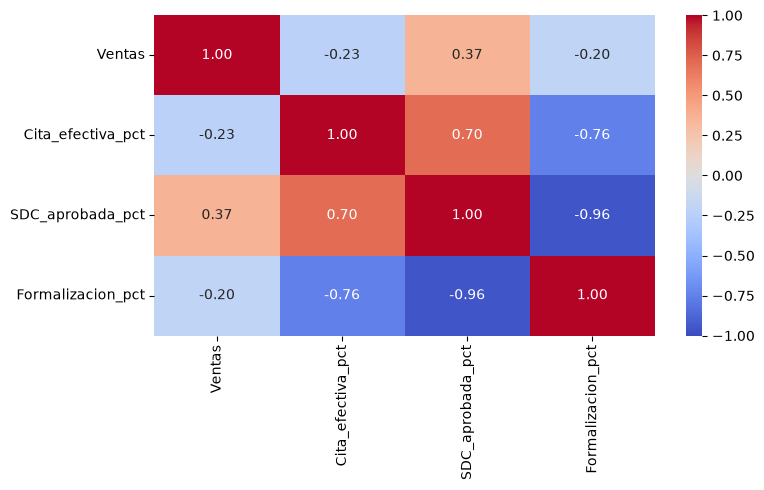

In [77]:
#Calculamos correlaciones
Corr_Factors = datos_limpios.corr()
display(Corr_Factors)
plt.figure(figsize=(8, 5))
sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

r: -0.20144026167626689 R2: 0.04057817902420202
Pendiente: -0.09489051094890512 Intercepto: 41.564963503649636


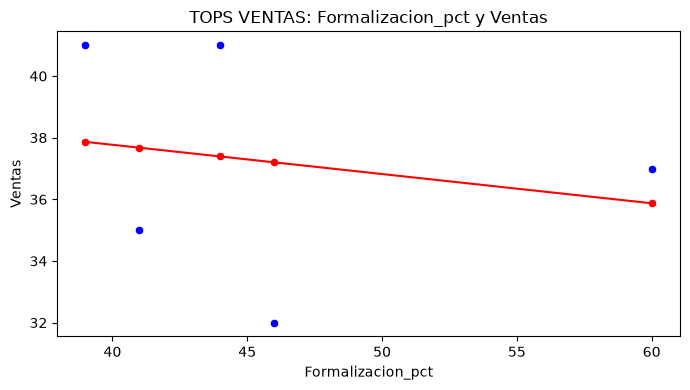

In [78]:
# Formalizacion_pct y Ventas: r = -0.201 y R2 = 0.041.
# Con solo cinco meses y una relacion debil, no se puede concluir que formalizar mas reduzca las ventas.
Vars_Indep = datos_limpios[['Formalizacion_pct']]
Var_Dep = datos_limpios['Ventas']
model = LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
coef_Deter = model.score(Vars_Indep, Var_Dep)
coef_Correl = Corr_Factors['Formalizacion_pct']['Ventas']
y_pred = model.predict(X=Vars_Indep)
grafica = datos_limpios.copy()
grafica.insert(0, "Predicciones", y_pred)
print("r:", coef_Correl, "R2:", coef_Deter)
print("Pendiente:", model.coef_[0], "Intercepto:", model.intercept_)
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Formalizacion_pct', y='Ventas', color="blue", data=grafica)
sns.scatterplot(x='Formalizacion_pct', y="Predicciones", color="red", data=grafica)
sns.lineplot(x='Formalizacion_pct', y="Predicciones", color="red", data=grafica)
plt.title('TOPS VENTAS: Formalizacion_pct y Ventas')
plt.tight_layout()
plt.show()
resultados.append(['TOPS VENTAS', 'Formalizacion_pct', 'Ventas', len(datos_limpios), coef_Correl, coef_Deter])

In [79]:
#Guardamos los datos limpios
datos_limpios.to_csv("Base_10_limpia.csv", index=False)

In [80]:
#Guardamos el resumen
resumen = pd.DataFrame(resultados, columns=["Base", "X", "Y", "Registros", "r", "R2"])
resumen.to_csv("Resultados_5_2.csv", index=False)
resumen.round(3)

,Base,X,Y,Registros,r,R2
0,Resumen,Efectivos,Ventas,30,0.601,0.361
1,Resumen,PDM,Ventas,30,0.826,0.681
2,SDC,Aprobadas,Formalizadas,31,0.933,0.870
3,Funnel,Programadas,Efectivas,18,0.955,0.912
4,Funnel,Efectivas,Ventas,18,0.343,0.117
5,Funnel,Aprobadas,Ventas,18,0.823,0.677
6,CPL FACEBOOK,Presupuesto,Leads,13,0.591,0.349
7,Marketing,Provision,Ventas,18,0.646,0.417
8,Citas Digital,PDM,Venta,664,0.167,0.028
9,Citas Digital,SDC,Venta,664,0.239,0.057


In [81]:
#Propuesta 1: probar recordatorios y reprogramacion de citas durante cuatro semanas.
# Medir asistencia y ventas por lead frente a un grupo con el seguimiento habitual.

In [82]:
#Propuesta 2: dar seguimiento a solicitudes aprobadas pendientes de formalizar.
# Registrar el motivo del pendiente y medir formalizaciones por cohorte de aprobacion.

In [83]:
#Propuesta 3: facilitar la agenda y disponibilidad de pruebas de manejo.
# Comparar ventas por lead en una prueba controlada antes de ampliar el cambio.

In [84]:
#Propuesta 4: registrar el canal de origen hasta la venta antes de mover presupuesto.
# Comparar conversion y costo por venta por canal; estas bases no permiten atribuir ese retorno.

In [85]:
# Las propuestas son pruebas a evaluar, no aumentos de ventas garantizados.
# Primero hay que conciliar los totales distintos y revisar las fechas de cada registro.